# Fingerprint Feature Analyzer — Dataset EDA

This notebook performs the initial exploratory data analysis of the NISTDB4 fingerprint dataset used by the project.

### Goals
- Verify the dataset path and folder structure
- Count images and classes
- Inspect optional train/validation/test split information without assuming it exists
- Check file formats, image modes, dimensions, and readability
- Inspect sample fingerprint images
- Examine pixel statistics and intensity distribution
- Produce a compact EDA summary for the next preprocessing stage

**Important:** This notebook does not train a model or modify the dataset.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Locate the project and dataset

The notebook is expected to be stored in `notebooks/`, so the project root is one directory above the notebook's working directory.

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "NISTDB4"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATASET_DIR)


Project root: c:\Users\johnm\fingerprint-feature-analyzer
Dataset path: c:\Users\johnm\fingerprint-feature-analyzer\data\raw\NISTDB4


In [3]:
if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_DIR}\n"
        "Expected structure: data/raw/NISTDB4/"
    )

print("Dataset exists: True")
print("Top-level contents:")

for path in sorted(DATASET_DIR.iterdir()):
    print(f"- {path.name} -> {'directory' if path.is_dir() else 'file'}")

Dataset exists: True
Top-level contents:
- class1_Arc -> directory
- class2_Whorl -> directory
- class3_Loop -> directory


## 2. Inspect the folder structure

The dataset may be organized only by class, or it may contain folders such as `train_set`, `val_set`, and `test_set`. The code below detects either arrangement instead of assuming one.

In [4]:
print("Dataset structure (directories only):\n")

for path in sorted(DATASET_DIR.rglob("*")):
    if path.is_dir():
        print(path.relative_to(DATASET_DIR))

Dataset structure (directories only):

class1_Arc
class2_Whorl
class3_Loop


## 3. Find all fingerprint images

In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_paths = sorted(
    path
    for path in DATASET_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)

print("Total images found:", len(image_paths))

Total images found: 2401


## 4. Build the dataset inventory

The class is taken from the first directory below `NISTDB4`. A split is detected only when a directory name explicitly contains `train`, `val`, `validation`, or `test`. Otherwise the split is recorded as `unspecified`.

In [6]:
SPLIT_MAP = {
    "train": "train",
    "train_set": "train",
    "training": "train",
    "val": "validation",
    "val_set": "validation",
    "validation": "validation",
    "validation_set": "validation",
    "test": "test",
    "test_set": "test",
}

records = []

for image_path in image_paths:
    relative_path = image_path.relative_to(DATASET_DIR)
    parts = relative_path.parts

    class_name = parts[0] if parts else "Unknown"

    detected_split = "unspecified"
    for part in parts[:-1]:
        normalized = part.strip().lower()
        if normalized in SPLIT_MAP:
            detected_split = SPLIT_MAP[normalized]
            break

    records.append({
        "filename": image_path.name,
        "path": str(image_path),
        "class": class_name,
        "split": detected_split,
        "extension": image_path.suffix.lower(),
    })

df = pd.DataFrame(records)

print("Dataset inventory created.")
print("Columns:", df.columns.tolist())
display(df.head())

Dataset inventory created.
Columns: ['filename', 'path', 'class', 'split', 'extension']


,filename,path,class,split,extension
0,class1_Arc_0001.png,c:\Users\johnm\fingerprint-feature-analyzer\da...,class1_Arc,unspecified,.png
1,class1_Arc_0002.png,c:\Users\johnm\fingerprint-feature-analyzer\da...,class1_Arc,unspecified,.png
2,class1_Arc_0003.png,c:\Users\johnm\fingerprint-feature-analyzer\da...,class1_Arc,unspecified,.png
3,class1_Arc_0004.png,c:\Users\johnm\fingerprint-feature-analyzer\da...,class1_Arc,unspecified,.png
4,class1_Arc_0005.png,c:\Users\johnm\fingerprint-feature-analyzer\da...,class1_Arc,unspecified,.png


## 5. Dataset counts

In [7]:
print(f"Total images: {len(df):,}")
print(f"Number of classes: {df['class'].nunique()}")

print("\nImages by class:")
display(df["class"].value_counts().rename_axis("class").reset_index(name="image_count"))

print("\nImages by split:")
display(df["split"].value_counts().rename_axis("split").reset_index(name="image_count"))

print("\nClass × split:")
display(pd.crosstab(df["class"], df["split"]))

Total images: 2,401
Number of classes: 3

Images by class:


,class,image_count
0,class1_Arc,801
1,class3_Loop,801
2,class2_Whorl,799



Images by split:


,split,image_count
0,unspecified,2401



Class × split:


split,unspecified
class,
class1_Arc,801
class2_Whorl,799
class3_Loop,801


## 6. Class distribution

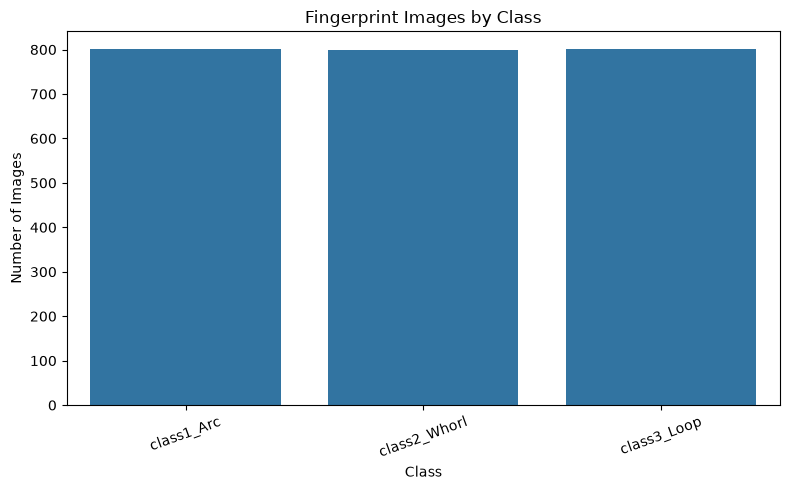

In [8]:
class_counts = df["class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Fingerprint Images by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 7. File formats

In [9]:
extension_counts = df["extension"].value_counts()
display(extension_counts.rename_axis("extension").reset_index(name="image_count"))

,extension,image_count
0,.png,2401


## 8. Image readability, dimensions, mode, and pixel statistics

We inspect every image. This catches corrupted files and unexpected image properties before preprocessing or model training.

In [10]:
image_metadata = []
failed_images = []

for path in image_paths:
    try:
        with Image.open(path) as img:
            img.load()
            arr = np.asarray(img)

            image_metadata.append({
                "filename": path.name,
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "shape": arr.shape,
                "dtype": str(arr.dtype),
                "min_pixel": int(arr.min()),
                "max_pixel": int(arr.max()),
                "mean_pixel": float(arr.mean()),
                "std_pixel": float(arr.std()),
            })
    except Exception as exc:
        failed_images.append({"path": str(path), "error": str(exc)})

metadata_df = pd.DataFrame(image_metadata)
failed_df = pd.DataFrame(failed_images)

print("Readable images:", len(metadata_df))
print("Unreadable images:", len(failed_df))

Readable images: 2401
Unreadable images: 0


In [11]:
print("Image dimensions:")
display(
    metadata_df.groupby(["width", "height"]).size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
)

print("Image modes:")
display(metadata_df["mode"].value_counts().rename_axis("mode").reset_index(name="image_count"))

print("Data types:")
display(metadata_df["dtype"].value_counts().rename_axis("dtype").reset_index(name="image_count"))

Image dimensions:


,width,height,image_count
0,512,512,2401


Image modes:


,mode,image_count
0,L,2401


Data types:


,dtype,image_count
0,uint8,2401


## 9. Sample fingerprint images

Display one sample from each detected class. This is a visual sanity check that the folder labels correspond to the expected fingerprint categories.

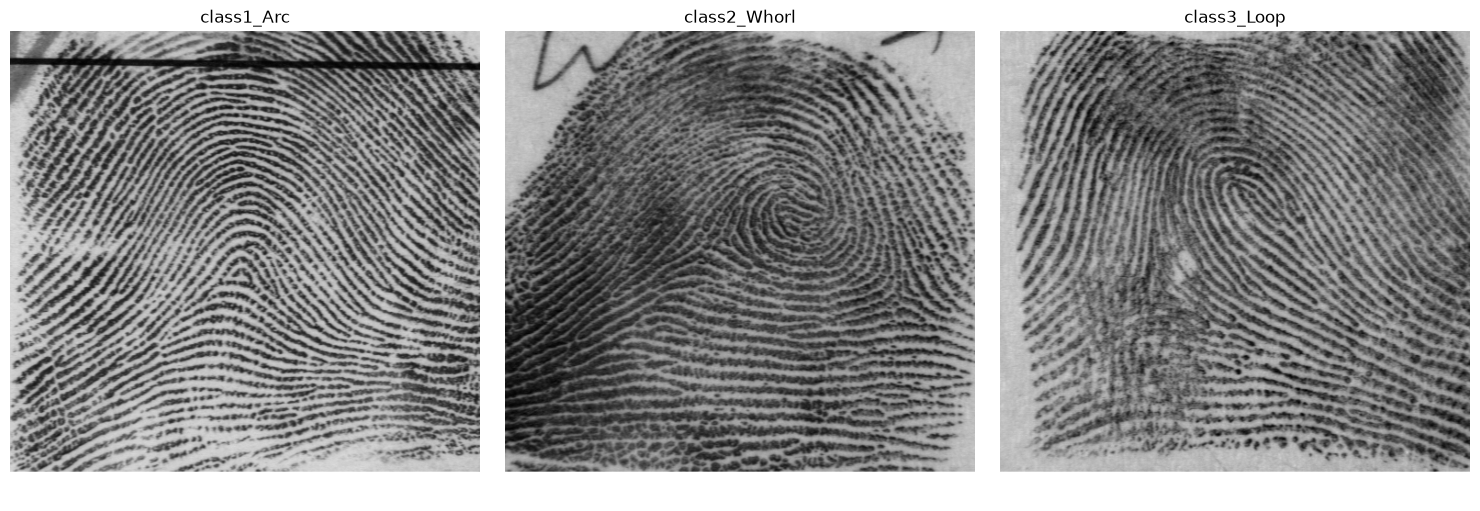

In [12]:
classes = sorted(df["class"].unique())
n_classes = len(classes)

fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 5))
axes = np.atleast_1d(axes)

for ax, class_name in zip(axes, classes):
    class_rows = df[df["class"] == class_name]
    image_path = Path(class_rows.iloc[0]["path"])

    with Image.open(image_path) as img:
        ax.imshow(img, cmap="gray")

    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 10. Inspect one image numerically

In [13]:
sample_path = Path(df.iloc[0]["path"])

with Image.open(sample_path) as sample_image:
    sample_array = np.asarray(sample_image)
    print("File:", sample_path.name)
    print("Format:", sample_image.format)
    print("Mode:", sample_image.mode)
    print("Size:", sample_image.size)
    print("Shape:", sample_array.shape)
    print("Data type:", sample_array.dtype)
    print("Minimum pixel value:", sample_array.min())
    print("Maximum pixel value:", sample_array.max())
    print("Mean pixel value:", round(float(sample_array.mean()), 3))
    print("Standard deviation:", round(float(sample_array.std()), 3))

File: class1_Arc_0001.png
Format: PNG
Mode: L
Size: (512, 512)
Shape: (512, 512)
Data type: uint8
Minimum pixel value: 8
Maximum pixel value: 255
Mean pixel value: 141.121
Standard deviation: 56.653


## 11. Pixel intensity distribution

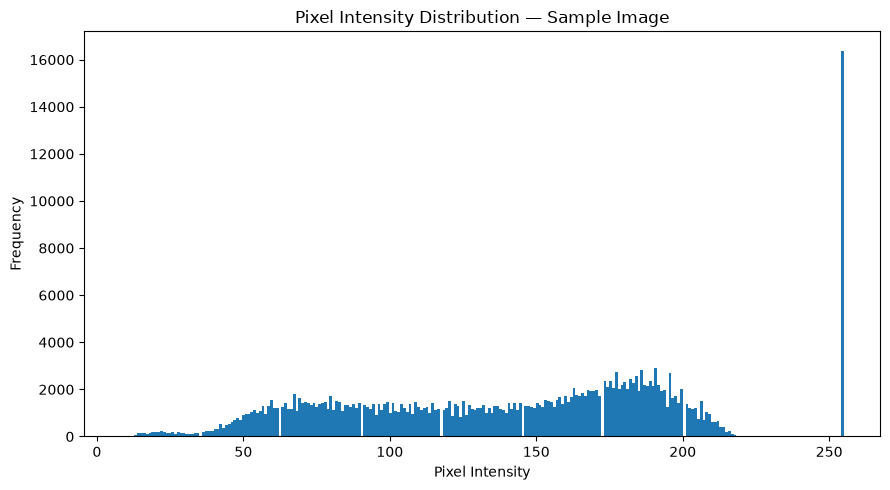

In [14]:
plt.figure(figsize=(9, 5))
plt.hist(sample_array.ravel(), bins=256)
plt.title("Pixel Intensity Distribution — Sample Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 12. Dataset-level pixel statistics

These statistics help us understand whether the dataset contains substantial variation in brightness and contrast.

In [15]:
pixel_summary = metadata_df[[
    "min_pixel",
    "max_pixel",
    "mean_pixel",
    "std_pixel",
]].describe().T

display(pixel_summary)

,count,mean,std,min,25%,50%,75%,max
min_pixel,2401.0,13.677218,12.567399,0.000000,3.000000,11.000000,21.000000,110.000000
max_pixel,2401.0,255.000000,0.000000,255.000000,255.000000,255.000000,255.000000,255.000000
mean_pixel,2401.0,124.532423,23.345806,43.165745,107.872372,125.238804,141.174141,199.626087
std_pixel,2401.0,55.746920,8.580366,21.389723,50.217331,55.721075,61.289511,96.127476


## 13. Final EDA summary

This cell creates a compact machine-readable summary that we can use when designing the preprocessing pipeline.

In [16]:
summary = {
    "total_images": int(len(df)),
    "classes": sorted(df["class"].unique().tolist()),
    "number_of_classes": int(df["class"].nunique()),
    "file_types": sorted(df["extension"].unique().tolist()),
    "splits_detected": sorted(df["split"].unique().tolist()),
    "readable_images": int(len(metadata_df)),
    "unreadable_images": int(len(failed_df)),
    "image_dimensions": sorted(
        [list(x) for x in metadata_df[["width", "height"]].drop_duplicates().itertuples(index=False, name=None)]
    ),
    "image_modes": sorted(metadata_df["mode"].unique().tolist()),
    "dtypes": sorted(metadata_df["dtype"].unique().tolist()),
}

summary

{'total_images': 2401,
 'classes': ['class1_Arc', 'class2_Whorl', 'class3_Loop'],
 'number_of_classes': 3,
 'file_types': ['.png'],
 'splits_detected': ['unspecified'],
 'readable_images': 2401,
 'unreadable_images': 0,
 'image_dimensions': [[512, 512]],
 'image_modes': ['L'],
 'dtypes': ['uint8']}

## EDA conclusion

The results above should be used to decide the next preprocessing steps. In particular, verify image dimensions, grayscale mode, readability, class balance, and whether an explicit train/validation/test split is present before model training.

**Next stage:** build a modular fingerprint preprocessing pipeline for grayscale conversion/normalization, noise reduction, contrast enhancement, segmentation, ridge enhancement, and orientation estimation.